In [3]:
import sys
sys.path.append('../src') 

In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from config import RESOLUTION, PROCESSED_DATA_DIR, TILE_SIZE

tensor_path = PROCESSED_DATA_DIR / f"worldclim_{RESOLUTION}_full.npy"

dataset_numpy = np.load(tensor_path, mmap_mode='r')

print(f"Loaded Array Shape: {dataset_numpy.shape}")

Loaded Array Shape: (3, 1080, 2160)


In [5]:
def visualize_terrain_data(data_input, title_prefix="WorldClim"):
    """
    Visualizes the 3-channel PyTorch tensor (Elevation, Precipitation, Temperature).
    Expects shape: [3, Height, Width]
    """
    if torch.is_tensor(data_input):
        data = data_input.cpu().numpy()
    else:
        data = data_input
    
    elev = data[0]
    precip = data[1]
    temp = data[2]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f"{title_prefix} Normalized Training Data", fontsize=18, fontweight='bold')

    im0 = axes[0].imshow(elev, cmap='terrain', vmin=0, vmax=1)
    axes[0].set_title("Elevation")
    axes[0].axis('off')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(precip, cmap='Blues', vmin=0, vmax=1)
    axes[1].set_title("Annual Precipitation")
    axes[1].axis('off')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(temp, cmap='coolwarm', vmin=0, vmax=1)
    axes[2].set_title("Annual Avg Temperature")
    axes[2].axis('off')
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

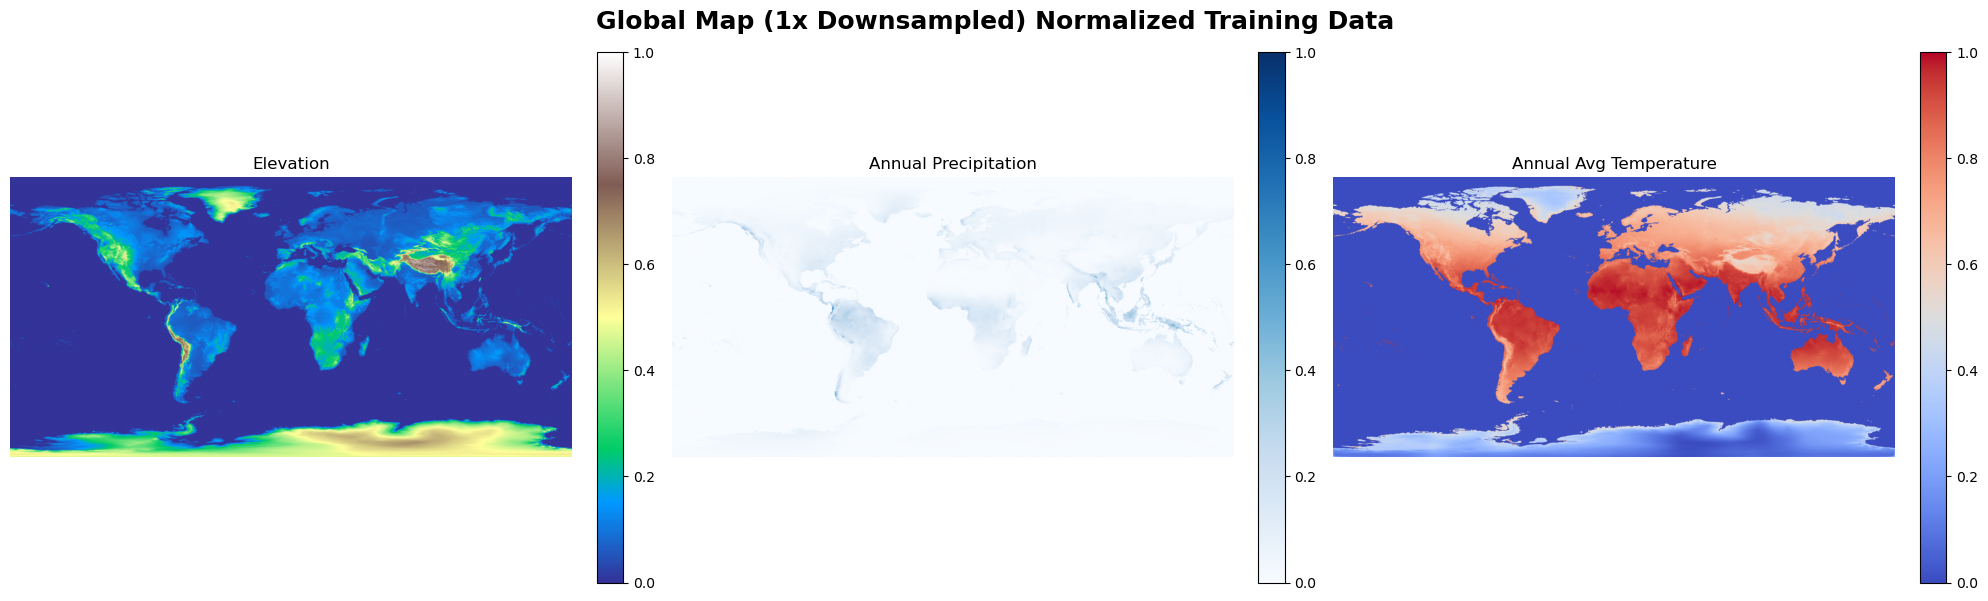

In [6]:
step = 1

downsampled_global = dataset_numpy[:, ::step, ::step] # Renderowanie całości przeładowuje mi RAM

visualize_terrain_data(downsampled_global, title_prefix=f"Global Map ({step}x Downsampled)")

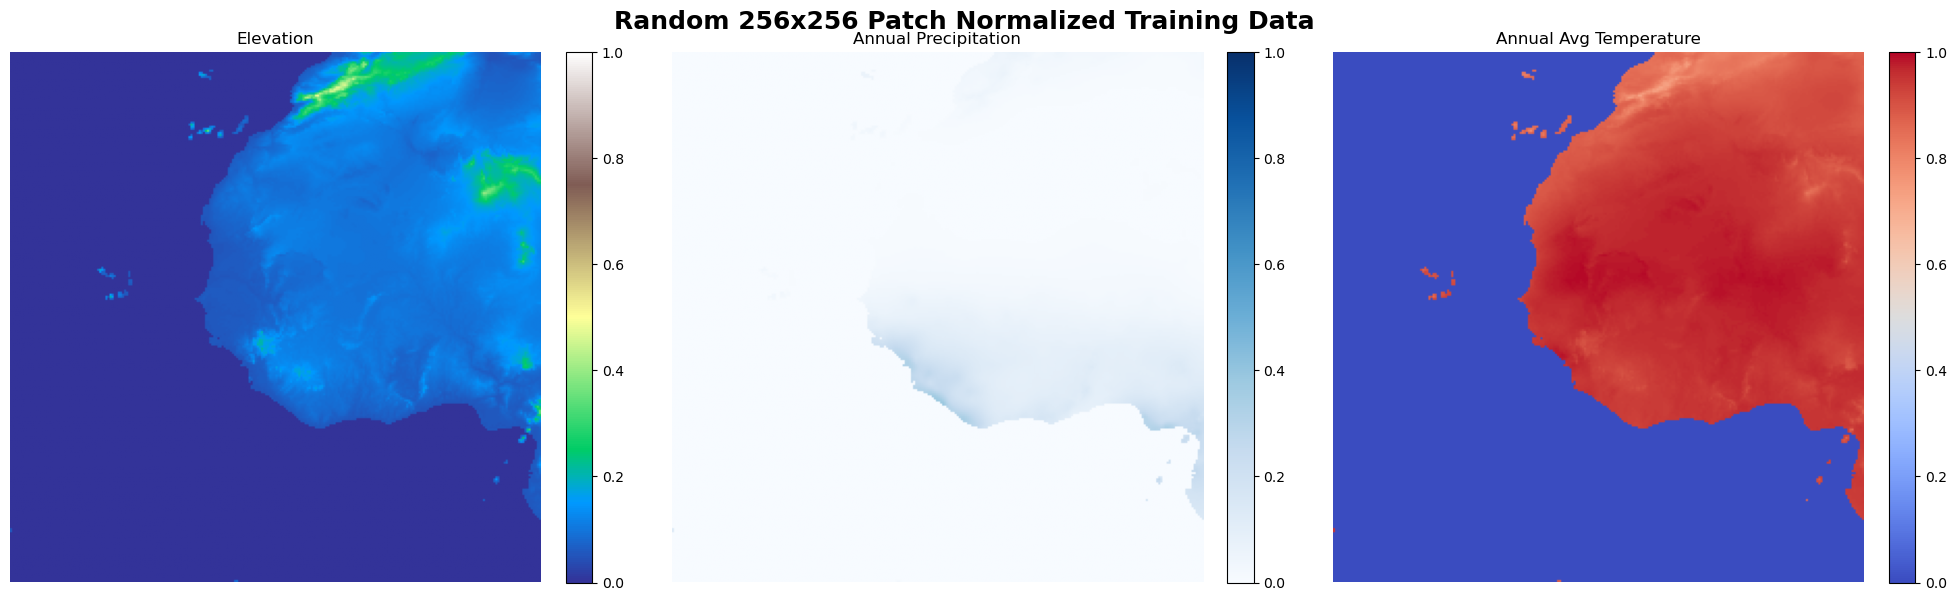

In [8]:
C, H, W = dataset_numpy.shape

y = np.random.randint(0, H - TILE_SIZE)
x = np.random.randint(0, W - TILE_SIZE)

patch_numpy = dataset_numpy[:, y:y+TILE_SIZE, x:x+TILE_SIZE]

patch_tensor = torch.from_numpy(patch_numpy).float()

visualize_terrain_data(patch_tensor, title_prefix=f"Random {TILE_SIZE}x{TILE_SIZE} Patch")

In [9]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / "src"))

from dataset import get_dataloader

dataloader = get_dataloader(batch_size=4)
batch = next(iter(dataloader))

print(f"Batch Shape: {batch.shape}")

Batch Shape: torch.Size([4, 3, 256, 256])
